# TimesFM 3 — factor forecast analysis

This notebook evaluates the zero-shot multivariate forecast produced by `forecast_factors.py`. It answers two separate questions:

1. **Did TimesFM improve historical forecasts?** Compare rolling out-of-sample errors with a zero-return baseline.
2. **What does the current forecast say?** Inspect the 20-step joint factor path and its marginal uncertainty.

The notebook reads saved CSV artifacts, so it is fast and does not reload the TimesFM checkpoint. A positive chart is not assumed to be meaningful: daily returns are noisy, and the aggregate result must survive a genuinely unseen holdout before downstream use.

## Prerequisite

Generate or refresh the artifacts from the repository root before running this notebook:

```powershell
python .\BinaryClassification\forecast_factors.py --model-dir .\BinaryClassification\model --output-dir .\BinaryClassification\timesfm_output --horizon 20 --context-length 1536 --device cuda --batch-size 2 --test-start 2024-08-07
```

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

# Resolve paths whether the notebook starts from the repo root or BinaryClassification/.
cwd = Path.cwd().resolve()
REPO = cwd.parent if cwd.name == 'BinaryClassification' else cwd
BC = REPO / 'BinaryClassification'
OUTPUT = BC / 'timesfm_output'
DOCS = REPO / 'docs' / 'img'
DOCS.mkdir(parents=True, exist_ok=True)
SAVE_FIGURES = True

INK, MUTED, GRAY = '#0b0b0b', '#52514e', '#c9c8c2'
BLUE, ORANGE, AQUA, RED = '#2a78d6', '#eb6834', '#1baf7a', '#e34948'
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': GRAY, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'text.color': INK, 'font.size': 10, 'axes.titlesize': 12,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

def finish(fig, filename):
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(DOCS / filename, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()

In [2]:
required = [
    'factor_point.csv', 'factor_quantiles.csv', 'backtest.csv',
    'backtest_metadata.json', 'metadata.json',
]
missing = [name for name in required if not (OUTPUT / name).exists()]
if missing:
    raise FileNotFoundError(
        f"Missing {', '.join(missing)} in {OUTPUT}. Run the prerequisite command first."
    )

point = pd.read_csv(OUTPUT / 'factor_point.csv', index_col=0)
point.index = point.index.astype(int)
quantiles = pd.read_csv(OUTPUT / 'factor_quantiles.csv', header=[0, 1], index_col=0)
quantiles.index = quantiles.index.astype(int)
quantiles.columns = pd.MultiIndex.from_tuples(
    [(factor, float(q)) for factor, q in quantiles.columns],
    names=['factor', 'quantile'],
)
metrics = pd.read_csv(OUTPUT / 'backtest.csv', index_col='factor')
metadata = json.loads((OUTPUT / 'metadata.json').read_text())
backtest_metadata = json.loads((OUTPUT / 'backtest_metadata.json').read_text())
factor_metrics = metrics.drop(index='__overall__')
overall = metrics.loc['__overall__']
horizon = int(metadata['horizon'])
windows = int(backtest_metadata['n_windows'])

summary = pd.DataFrame({
    'Value': [
        metadata['context_end'], backtest_metadata['history_start'],
        backtest_metadata['train_end'], backtest_metadata['test_start'],
        backtest_metadata['test_end'], backtest_metadata['context_length'],
        backtest_metadata['first_context_observations'],
        horizon, windows, int(overall['n']),
        overall['mae_skill_vs_zero'], overall['directional_accuracy'],
    ]
}, index=[
    'Forecast origin', 'Factor-history start', 'Pre-holdout end',
    'Holdout start', 'Holdout end', 'Requested context length',
    'First-origin context observations',
    'Forecast horizon', 'Backtest windows',
    'Factor-step predictions', 'MAE skill vs zero', 'Directional accuracy',
])
summary.loc['MAE skill vs zero', 'Value'] = f"{overall['mae_skill_vs_zero']:.2%}"
summary.loc['Directional accuracy', 'Value'] = f"{overall['directional_accuracy']:.1%}"
display(summary)

,Value
Forecast origin,2026-08-07 00:00:00+00:00
Factor-history start,2018-11-20 00:00:00+00:00
Pre-holdout end,2024-08-06 00:00:00+00:00
Holdout start,2024-08-07 00:00:00+00:00
Holdout end,2026-08-05 00:00:00+00:00
Requested context length,1536
First-origin context observations,1435
Forecast horizon,20
Backtest windows,25
Factor-step predictions,7500


## Why eight years of data does not guarantee forecast improvement

The raw OHLCV pickle spans May 2018–August 2026, but style-exposure burn-in means usable 15-factor returns begin in November 2018. More importantly, the factor model's cross-sectional $R^2$ measures how well known exposures explain stocks **on the same day**. The TimesFM backtest asks the harder question of whether past factor returns predict future factor returns. Daily returns can be well explained contemporaneously and still be close to unpredictable through time.

TimesFM 3 is used zero-shot here: no weights are fitted on the first period. The pre-holdout observations are causal context. The fixed walk-forward holdout begins August 7, 2024; every forecast uses only information available before that forecast origin, while later origins may use observations already revealed earlier in the holdout.

## 1. Historical improvement versus predicting zero

MAE skill is $1 - \mathrm{MAE}_{TimesFM}/\mathrm{MAE}_{zero}$, so positive values are improvements and negative values are regressions. Directional accuracy is shown separately because a model can predict signs slightly better while failing to improve return magnitudes.

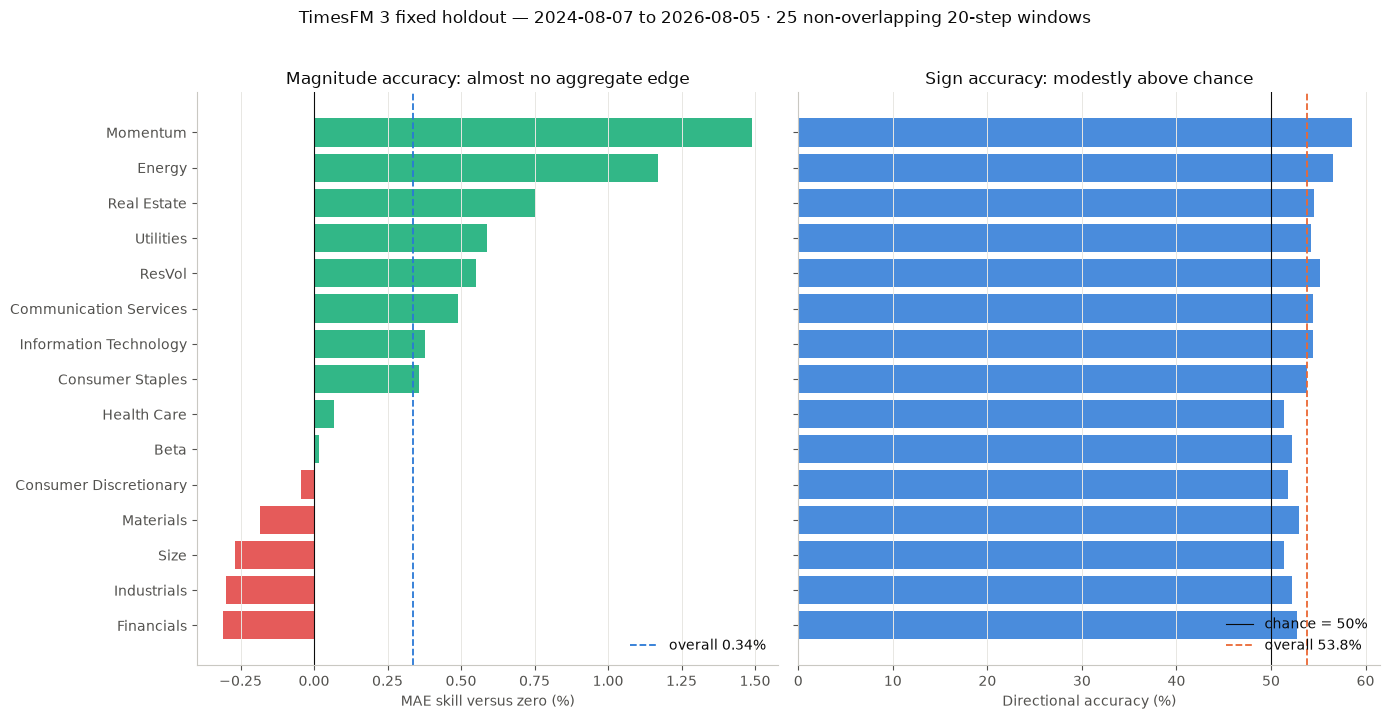

In [3]:
ordered = factor_metrics['mae_skill_vs_zero'].sort_values().index
skill_pct = factor_metrics.loc[ordered, 'mae_skill_vs_zero'] * 100
direction_pct = factor_metrics.loc[ordered, 'directional_accuracy'] * 100
colors = np.where(skill_pct >= 0, AQUA, RED)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
axes[0].barh(ordered, skill_pct, color=colors, alpha=0.9)
axes[0].axvline(0, color=INK, lw=0.8)
axes[0].axvline(overall['mae_skill_vs_zero'] * 100, color=BLUE, ls='--', lw=1.3,
                label=f"overall {overall['mae_skill_vs_zero']:.2%}")
axes[0].set_xlabel('MAE skill versus zero (%)')
axes[0].set_title('Magnitude accuracy: almost no aggregate edge')
axes[0].legend(frameon=False, loc='lower right')
axes[0].grid(axis='x', color='#e8e7e3', lw=0.7)

axes[1].barh(ordered, direction_pct, color=BLUE, alpha=0.85)
axes[1].axvline(50, color=INK, lw=0.8, label='chance = 50%')
axes[1].axvline(overall['directional_accuracy'] * 100, color=ORANGE, ls='--', lw=1.3,
                label=f"overall {overall['directional_accuracy']:.1%}")
axes[1].set_xlabel('Directional accuracy (%)')
axes[1].set_title('Sign accuracy: modestly above chance')
axes[1].grid(axis='x', color='#e8e7e3', lw=0.7)
axes[1].legend(frameon=False, loc='lower right')
fig.suptitle(
    f"TimesFM 3 fixed holdout — {backtest_metadata['test_start'][:10]} to "
    f"{backtest_metadata['test_end'][:10]} · {windows} non-overlapping {horizon}-step windows",
    y=1.02,
)
finish(fig, 'timesfm_backtest_skill.png')

In [4]:
best_skill = factor_metrics['mae_skill_vs_zero'].idxmax()
best_direction = factor_metrics['directional_accuracy'].idxmax()
positive = int((factor_metrics['mae_skill_vs_zero'] > 0).sum())
print(f"{positive}/{len(factor_metrics)} factors beat zero on MAE.")
print(
    f"Best MAE skill: {best_skill} "
    f"({factor_metrics.loc[best_skill, 'mae_skill_vs_zero']:+.2%})."
)
print(
    f"Best directional accuracy: {best_direction} "
    f"({factor_metrics.loc[best_direction, 'directional_accuracy']:.1%})."
)
print(
    f"Overall MAE skill is {overall['mae_skill_vs_zero']:+.2%}: "
    "the fixed holdout shows whether magnitude accuracy improves beyond zero."
)

10/15 factors beat zero on MAE.
Best MAE skill: Momentum (+1.49%).
Best directional accuracy: Momentum (58.6%).
Overall MAE skill is +0.34%: the fixed holdout shows whether magnitude accuracy improves beyond zero.


## 2. Current joint factor forecast

The following paths compound the median point forecasts. They are conditional factor-return forecasts from the final context row, not expected stock returns and not a replacement for the covariance risk model.

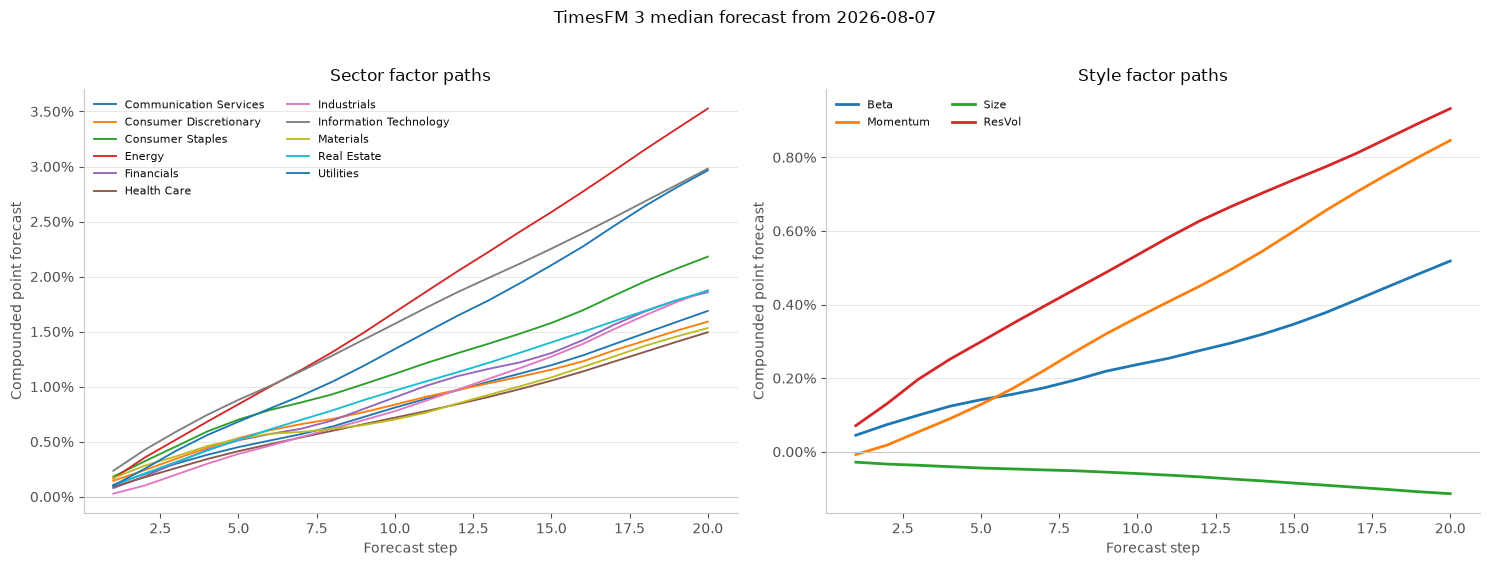

In [5]:
styles = [x for x in ['Beta', 'Momentum', 'Size', 'ResVol'] if x in point.columns]
sectors = [x for x in point.columns if x not in styles]
cumulative = (1 + point).cumprod() - 1

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for factor in sectors:
    axes[0].plot(cumulative.index, cumulative[factor], lw=1.35, label=factor)
for factor in styles:
    axes[1].plot(cumulative.index, cumulative[factor], lw=2, label=factor)
for ax, title in zip(axes, ['Sector factor paths', 'Style factor paths']):
    ax.axhline(0, color=GRAY, lw=0.8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    ax.set_xlabel('Forecast step')
    ax.set_ylabel('Compounded point forecast')
    ax.set_title(title)
    ax.grid(axis='y', color='#e8e7e3', lw=0.7)
    ax.legend(frameon=False, fontsize=8, ncol=2)
fig.suptitle(f"TimesFM 3 median forecast from {metadata['context_end'][:10]}", y=1.02)
finish(fig, 'timesfm_factor_paths.png')

## 3. Marginal forecast uncertainty

TimesFM supplies nine marginal quantiles per factor and step. The bands below are valid pointwise uncertainty summaries. They are **not joint simulated paths**, so quantile rows should not be compounded or summed into portfolio quantiles.

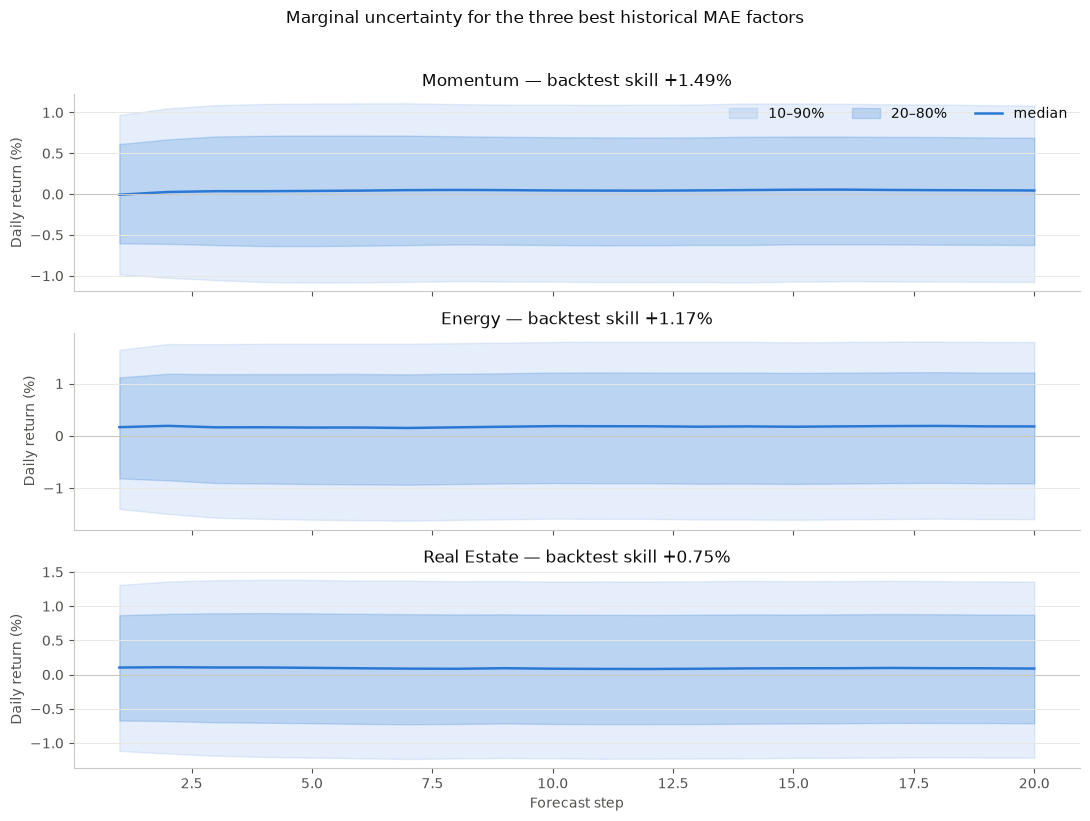

In [6]:
leaders = factor_metrics['mae_skill_vs_zero'].nlargest(3).index.tolist()
fig, axes = plt.subplots(len(leaders), 1, figsize=(11, 8), sharex=True)
steps = point.index.to_numpy()
for ax, factor in zip(np.atleast_1d(axes), leaders):
    q10 = quantiles[(factor, 0.1)].to_numpy() * 100
    q20 = quantiles[(factor, 0.2)].to_numpy() * 100
    q80 = quantiles[(factor, 0.8)].to_numpy() * 100
    q90 = quantiles[(factor, 0.9)].to_numpy() * 100
    median = point[factor].to_numpy() * 100
    ax.fill_between(steps, q10, q90, color=BLUE, alpha=0.12, label='10–90%')
    ax.fill_between(steps, q20, q80, color=BLUE, alpha=0.22, label='20–80%')
    ax.plot(steps, median, color=BLUE, lw=1.8, label='median')
    ax.axhline(0, color=GRAY, lw=0.8)
    ax.set_ylabel('Daily return (%)')
    ax.set_title(
        f"{factor} — backtest skill {factor_metrics.loc[factor, 'mae_skill_vs_zero']:+.2%}"
    )
    ax.grid(axis='y', color='#e8e7e3', lw=0.7)
axes[0].legend(frameon=False, ncol=3, loc='upper right')
axes[-1].set_xlabel('Forecast step')
fig.suptitle('Marginal uncertainty for the three best historical MAE factors', y=1.02)
finish(fig, 'timesfm_quantile_fans.png')

## Interpretation

- The date-based final holdout is the decision-relevant result; aggregate MAE skill should be interpreted together with its small absolute size.
- Slightly better directional accuracy may be useful for ranking or sign decisions, but it needs a trading-cost-aware test and confidence intervals.
- The best-looking factors were selected after observing the same backtest. Treat them as hypotheses, not confirmed alpha.
- The strongest next test is to preserve the saved forecast and score it against OHLCV strictly after the recorded forecast origin. Do not tune the model on that holdout first.

TimesFM 3 checkpoint weights are currently restricted to non-commercial, non-production use.